## 深度学习实践大作业（多特征股票预测）

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['SimHei']  #设置中文字体为黑体
plt.rcParams['axes.unicode_minus'] = False  #解决负号显示问题

In [2]:
import pandas as pd

# 加载数据
data = pd.read_excel('sharehold.xlsx', sheet_name='Sheet1')


# 创建日期为索引
data.set_index('日期', inplace=True)

# 特征选择
features = ['前收盘价(元)', '开盘价(元)', '最高价(元)', '最低价(元)', '成交量(股)'] 
X = data[features]
y = data['收盘价(元)']

## 导入数据+数据预处理

In [3]:
import pandas as pd

# 加载数据
data = pd.read_excel('sharehold.xlsx', sheet_name='Sheet1')

# 查看每列的缺失值情况
missing_values = data.isnull().sum()
print("Missing values in each column:\n", missing_values)

# 如果有缺失值，可以选择填充或删除
# 例如，使用前向填充方法来填充缺失值
data.fillna(method='ffill', inplace=True)

# 或者使用后向填充方法
# data.fillna(method='bfill', inplace=True)

# 或者简单地删除含有缺失值的行
# data.dropna(inplace=True)

Missing values in each column:
 代码           0
简称           0
日期           0
前收盘价(元)      0
开盘价(元)       0
最高价(元)       0
最低价(元)       0
收盘价(元)       0
成交量(股)       0
成交金额(元)      0
涨跌(元)        0
涨跌幅(%)       0
均价(元)        0
换手率(%)       0
A股流通市值(元)    0
总市值(元)       0
市盈率          0
市净率          0
市销率          0
市现率          0
dtype: int64


In [4]:
# 检查每个数值列中零值的数量
zero_values = (data == 0).sum()
print("Zero values in each column:\n", zero_values)

# 根据具体情况决定如何处理零值。
# 例如，如果'成交量(股)'中的零值不合理，可以考虑用均值、中位数或其他统计量替换。
# 这里以'成交量(股)'为例，使用该列的平均值替换零值
if '成交量(股)' in zero_values.index and zero_values['成交量(股)'] > 0:
    # 计算非零值的平均值
    non_zero_mean = data['成交量(股)'][data['成交量(股)'] != 0].mean()
    # 使用非零均值替换零值
    data['成交量(股)'].replace(0, non_zero_mean, inplace=True)

Zero values in each column:
 代码            0
简称            0
日期            0
前收盘价(元)       0
开盘价(元)        0
最高价(元)        0
最低价(元)        0
收盘价(元)        0
成交量(股)        0
成交金额(元)       0
涨跌(元)        42
涨跌幅(%)       42
均价(元)         0
换手率(%)        0
A股流通市值(元)     0
总市值(元)        0
市盈率           0
市净率           0
市销率           0
市现率           0
dtype: int64


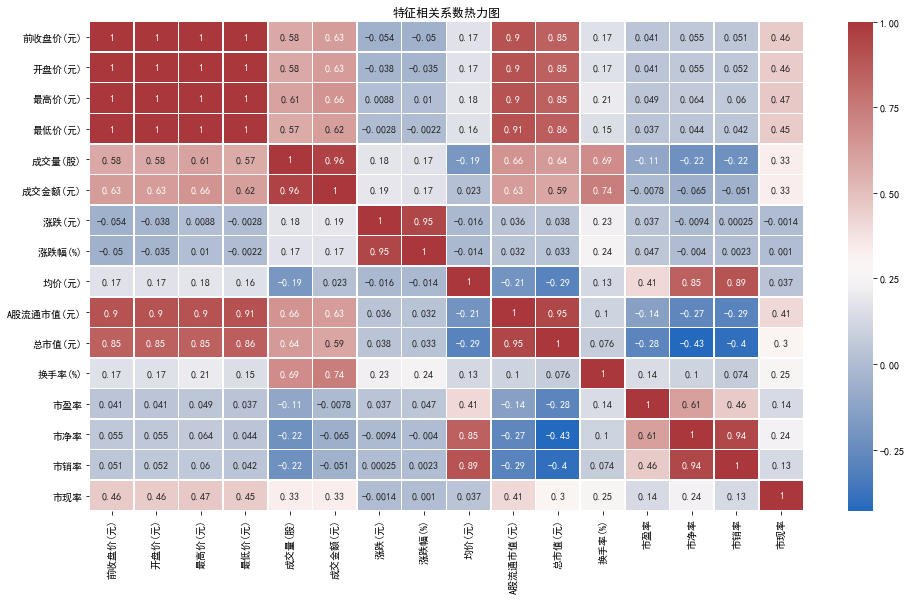

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 加载数据
data = pd.read_excel('sharehold.xlsx', sheet_name='Sheet1')

# 选择感兴趣的特征列（去掉非数值列如日期）
features = ['前收盘价(元)', '开盘价(元)', '最高价(元)', '最低价(元)', '成交量(股)','成交金额(元)',

            '涨跌(元)', '涨跌幅(%)','均价(元)','A股流通市值(元)','总市值(元)',

            '换手率(%)', '市盈率', '市净率', '市销率', '市现率']
df_selected = data[features]

# 计算相关系数矩阵
corr_matrix = df_selected.corr()

# 使用Seaborn绘制热力图
plt.figure(figsize=(16, 9))  # 设置图形大小
sns.heatmap(corr_matrix, annot=True, cmap='vlag', linewidths=0.5)  # 绘制热力图


# 显示图形
plt.title('特征相关系数热力图')
plt.show()

## PCA

In [6]:
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity

# 进行KMO检验
kmo_all, kmo_model = calculate_kmo(df_selected)
print("KMO检验值：", kmo_model)

# 进行Bartlett球形检验
chi_square_value, p_value = calculate_bartlett_sphericity(df_selected)
print("Bartlett球形检验卡方值：", chi_square_value)
print("Bartlett检验p值：", p_value)

KMO检验值： 0.7901817757235623
Bartlett球形检验卡方值： 79098.30280593815
Bartlett检验p值： 0.0


In [7]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 标准化数据（非常重要）
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_selected)

# 设置保留95%信息的PCA
pca = PCA(n_components=0.95)  # 自动选择保留95%方差的主成分数量
pca.fit(df_scaled)

# 获取解释方差比
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = explained_variance_ratio.cumsum()

print("各主成分解释方差比：")
for i, var in enumerate(explained_variance_ratio):
    print(f"PC{i+1}: {var:.4f}")

print("\n累计方差贡献率：")
for i, cum_var in enumerate(cumulative_variance):
    print(f"前{i+1}个主成分累计解释方差: {cum_var:.4f}")

各主成分解释方差比：
PC1: 0.4361
PC2: 0.2172
PC3: 0.1438
PC4: 0.0856
PC5: 0.0508
PC6: 0.0403

累计方差贡献率：
前1个主成分累计解释方差: 0.4361
前2个主成分累计解释方差: 0.6533
前3个主成分累计解释方差: 0.7971
前4个主成分累计解释方差: 0.8828
前5个主成分累计解释方差: 0.9336
前6个主成分累计解释方差: 0.9738


D:\Anaconda\lib\site-packages\sklearn\linear_model\least_angle.py:35: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  eps=np.finfo(np.float).eps,
D:\Anaconda\lib\site-packages\sklearn\linear_model\least_angle.py:597: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  eps=np.finfo(np.float).eps, copy_X=True, fit_path=True,
D:\Anaconda\lib\site-pa

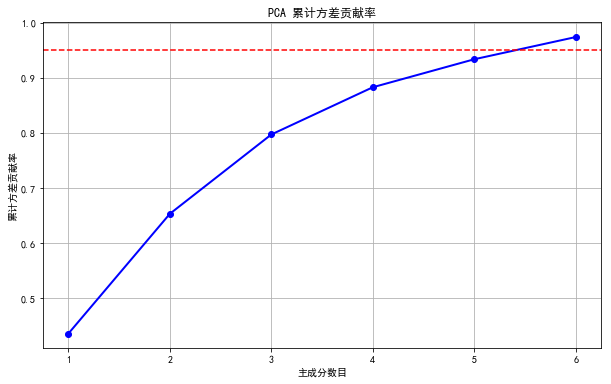

In [8]:
import numpy as np

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'bo-', linewidth=2)
plt.axhline(y=0.95, color='r', linestyle='--')
plt.xlabel('主成分数目')
plt.ylabel('累计方差贡献率')
plt.title('PCA 累计方差贡献率')
plt.grid(True)
plt.show()

In [9]:
# 获取载荷矩阵
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

# 创建DataFrame以便更好地展示数据
loadings_df = pd.DataFrame(loadings, columns=[f'PC{i+1}' for i in range(loadings.shape[1])], index=df_selected.columns)
print(loadings_df)

                PC1       PC2       PC3       PC4       PC5       PC6
前收盘价(元)    0.950592  0.169383 -0.212283 -0.125532  0.045944  0.026024
开盘价(元)     0.951350  0.170101 -0.200301 -0.135921  0.047168  0.025405
最高价(元)     0.959854  0.179759 -0.146296 -0.134912  0.048235  0.021187
最低价(元)     0.950615  0.158835 -0.182566 -0.173278  0.042332  0.027151
成交量(股)     0.781722 -0.145462  0.388347  0.402977  0.067172  0.016119
成交金额(元)    0.793326  0.037288  0.393587  0.400957  0.149611  0.019604
涨跌(元)      0.070336 -0.003731  0.844991 -0.504306 -0.021082 -0.030207
涨跌幅(%)     0.068246  0.003253  0.845297 -0.503624 -0.029205 -0.023341
均价(元)     -0.015342  0.910506 -0.045834 -0.056905  0.324583 -0.119333
A股流通市值(元)  0.942012 -0.192078 -0.128310 -0.155129 -0.045195  0.054643
总市值(元)     0.902187 -0.335414 -0.129799 -0.168936  0.048138  0.025315
换手率(%)     0.348057  0.179355  0.620756  0.621348  0.048085 -0.009811
市盈率       -0.053568  0.657583  0.082151  0.027491 -0.328517  0.668909
市净率       -0.109964 

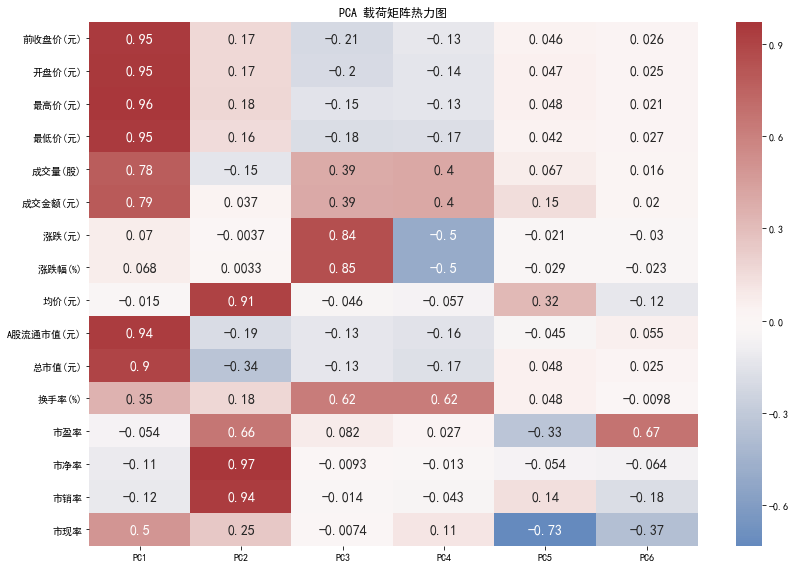

In [11]:
plt.figure(figsize=(12, 8))  # 设置图形大小
sns.heatmap(loadings_df, annot=True, cmap='vlag', center=0,annot_kws={"size": 14})  # 绘制热力图

# 绘制热图，并通过 annot_kws 增大字体大小
#sns.heatmap(loadings, annot=True, cmap='vlag', center=0, fmt='.2f', linewidths=0.5, 
 #           annot_kws={"size": 14})  # 设置注释文字大小为14


# 添加标题和调整布局
plt.title('PCA 载荷矩阵热力图')
plt.tight_layout()  # 自动调整子图参数,使之填充整个图像区域
plt.show()

In [11]:
# 获取前3个主成分的数据
X_pca = pca.transform(df_scaled)[:, :6]  # 取前3个主成分

# 目标变量：收盘价
y = data['收盘价(元)'].values

In [12]:
from sklearn.model_selection import train_test_split

# 划分训练集和测试集（80% 训练，20% 测试）
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.02, shuffle=False)

print("训练集大小:", len(X_train))
print("测试集大小:", len(X_test))


训练集大小: 1928
测试集大小: 40


## LSTM

In [84]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.dates as mdates

# 定义窗口函数
def create_dataset(X, y, time_steps=1):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        v = X[i:(i + time_steps)]
        Xs.append(v)
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

# 设置时间步长
time_steps = 5

# 生成LSTM需要的3D输入 (samples, time_steps, features)
X_lstm, y_lstm = create_dataset(X_pca, y, time_steps)

# 划分训练集和测试集
split = int(len(X_lstm) * 0.98)
X_train, X_test = X_lstm[:split], X_lstm[split:]
y_train, y_test = y_lstm[:split], y_lstm[split:]

In [85]:
model = Sequential()
model.add(LSTM(128, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

# 训练模型
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1, verbose=1)

Epoch 1/20
55/55 [==============================] - 3s 16ms/step - loss: 35.9486 - val_loss: 0.7821
Epoch 2/20
55/55 [==============================] - 0s 6ms/step - loss: 1.0671 - val_loss: 0.3916
Epoch 3/20
55/55 [==============================] - 0s 6ms/step - loss: 0.5412 - val_loss: 0.3037
Epoch 4/20
55/55 [==============================] - 0s 7ms/step - loss: 0.3381 - val_loss: 0.1773
Epoch 5/20
55/55 [==============================] - 0s 5ms/step - loss: 0.2168 - val_loss: 0.2205
Epoch 6/20
55/55 [==============================] - 0s 5ms/step - loss: 0.1471 - val_loss: 0.2689
Epoch 7/20
55/55 [==============================] - 0s 5ms/step - loss: 0.1146 - val_loss: 0.3108
Epoch 8/20
55/55 [==============================] - 0s 5ms/step - loss: 0.0977 - val_loss: 0.2466
Epoch 9/20
55/55 [==============================] - 0s 5ms/step - loss: 0.0912 - val_loss: 0.4183
Epoch 10/20
55/55 [==============================] - 0s 6ms/step - loss: 0.0851 - val_loss: 0.2582
Epoch 11/20
55/55

In [86]:
import matplotlib.dates as mdates
from matplotlib.dates import DateFormatter

# 获取对应的日期作为x轴
dates = pd.to_datetime(data['日期'])
test_dates = dates.iloc[-len(y_test):]


2/2 [==============================] - 0s 3ms/step
MSE: 0.5911, R²: -16.3134


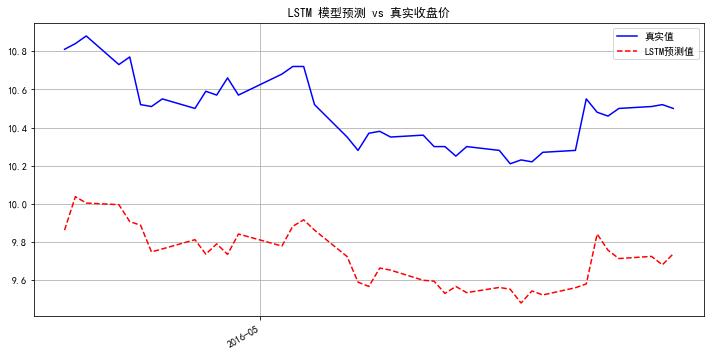

In [87]:
# 预测
y_pred = model.predict(X_test)

# 反标准化（如果你之前对y做了标准化）
# 如果未标准化，则直接使用原始值即可

# 评估
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MSE: {mse:.4f}, R²: {r2:.4f}")

# 可视化
test_dates = dates.iloc[-len(y_test):]

plt.figure(figsize=(12, 6))
plt.plot(test_dates, y_test, label='真实值', color='blue')
plt.plot(test_dates, y_pred, label='LSTM预测值', color='red', linestyle='--')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.gcf().autofmt_xdate()
plt.title('LSTM 模型预测 vs 真实收盘价')
plt.legend()
plt.grid(True)
plt.show()

## GRU

In [94]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout

# 假设 X_train, X_test, y_train, y_test 已定义

In [95]:
model_gru = Sequential()
model_gru.add(GRU(64, input_shape=(X_train.shape[1], X_train.shape[2])))
model_gru.add(Dropout(0.2))
model_gru.add(Dense(1))
model_gru.compile(optimizer='adam', loss='mse')

# 训练
history_gru = model_gru.fit(X_train, y_train, epochs=20, batch_size=32,
                            validation_split=0.1, verbose=0)

In [96]:
y_pred_gru = model_gru.predict(X_test)

mse_gru = mean_squared_error(y_test, y_pred_gru)
r2_gru = r2_score(y_test, y_pred_gru)
print(f"GRU - MSE: {mse_gru:.4f}, R²: {r2_gru:.4f}")

2/2 [==============================] - 0s 3ms/step
GRU - MSE: 0.2582, R²: -6.5618


GRU - MSE: 0.2582, R²: -6.5618


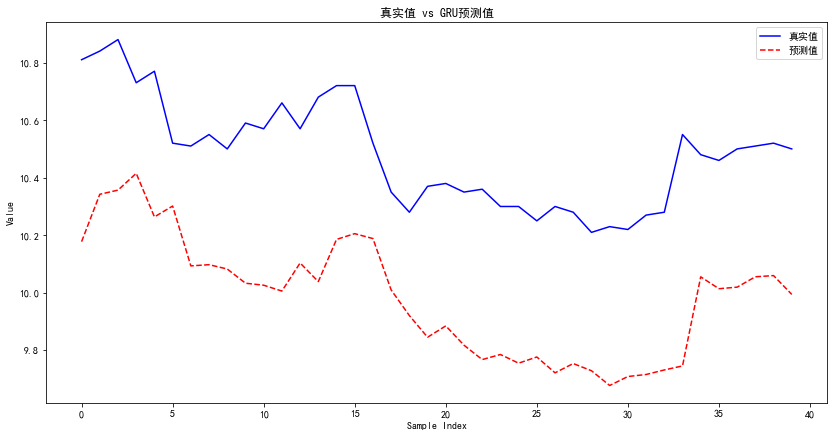

In [97]:
import matplotlib.pyplot as plt
from sklearn.metrics import mea0.2582n_squared_error, r2_score

# 假设已加载模型并进行了预测，y_test是测试集的真实标签，y_pred_gru是GRU模型对测试集的预测值
# y_pred_gru = model_gru.predict(X_test)

mse_gru = mean_squared_error(y_test, y_pred_gru)
r2_gru = r2_score(y_test, y_pred_gru)
print(f"GRU - MSE: {mse_gru:.4f}, R²: {r2_gru:.4f}")

def plot_predictions(actual, predicted):
    """
    绘制实际值与预测值的对比图。
    
    参数:
        actual (numpy.ndarray): 实际值数组。
        predicted (numpy.ndarray): 预测值数组。
    """
    plt.figure(figsize=(14,7))
    plt.plot(actual, label='真实值', color='blue')
    plt.plot(predicted, label='预测值', color='red', linestyle='--')
    plt.title('真实值 vs GRU预测值')
    plt.xlabel('Sample Index')
    plt.ylabel('Value')
    plt.legend()
    plt.show()

# 确保预测值和实际值形状匹配
plot_predictions(y_test.flatten(), y_pred_gru.flatten())

## ALSTM

Epoch 1/20
28/28 [==============================] - 3s 27ms/step - loss: 64.2232 - val_loss: 121.7726
Epoch 2/20
28/28 [==============================] - 0s 6ms/step - loss: 46.4207 - val_loss: 90.1840
Epoch 3/20
28/28 [==============================] - 0s 7ms/step - loss: 14.9610 - val_loss: 20.1376
Epoch 4/20
28/28 [==============================] - 0s 8ms/step - loss: 2.9899 - val_loss: 1.5788
Epoch 5/20
28/28 [==============================] - 0s 6ms/step - loss: 1.2236 - val_loss: 0.4712
Epoch 6/20
28/28 [==============================] - 0s 7ms/step - loss: 0.9937 - val_loss: 0.4641
Epoch 7/20
28/28 [==============================] - 0s 6ms/step - loss: 0.9001 - val_loss: 0.4309
Epoch 8/20
28/28 [==============================] - 0s 6ms/step - loss: 0.9213 - val_loss: 0.4859
Epoch 9/20
28/28 [==============================] - 0s 6ms/step - loss: 0.7753 - val_loss: 0.4934
Epoch 10/20
28/28 [==============================] - 0s 6ms/step - loss: 0.7118 - val_loss: 0.4400
Epoch 11/20

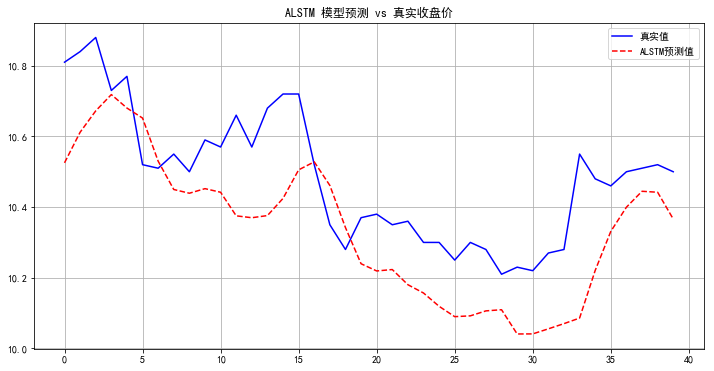

In [101]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Layer
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow.keras.backend as K
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt


# 自定义注意力层
class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name='attention_weight', shape=(input_shape[-1], 1),
                                 initializer='random_normal', trainable=True)
        self.b = self.add_weight(name='attention_bias', shape=(input_shape[1], 1),
                                 initializer='zeros', trainable=True)
        super(AttentionLayer, self).build(input_shape)

    def call(self, inputs):
        # 输入维度 (batch_size, time_steps, features)
        e = K.tanh(K.dot(inputs, self.W) + self.b)
        a = K.softmax(e, axis=1)
        output = inputs * a
        return K.sum(output, axis=1)

    def compute_output_shape(self, input_shape):
        return input_shape[0], input_shape[-1]


# 数据预处理
def create_dataset(X, y, time_steps=1):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        v = X[i:(i + time_steps)]
        Xs.append(v)
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)


# 假设X_pca已经准备好，y为目标变量（收盘价）
time_steps = 5
X_lstm, y_lstm = create_dataset(X_pca, y, time_steps)

split = int(len(X_lstm) * 0.98)
X_train, X_test = X_lstm[:split], X_lstm[split:]
y_train, y_test = y_lstm[:split], y_lstm[split:]


# 构建ALSTM模型
def build_alstm_model(time_steps, n_features):
    inputs = Input(shape=(time_steps, n_features))
    lstm_out = LSTM(units=64, return_sequences=True)(inputs)
    attention_out = AttentionLayer()(lstm_out)
    dropout = Dropout(0.2)(attention_out)
    outputs = Dense(1)(dropout)
    model = Model(inputs=[inputs], outputs=[outputs])
    return model


model = build_alstm_model(time_steps, X_train.shape[2])

# 编译模型
model.compile(optimizer=Adam(lr=0.001), loss='mean_squared_error')

# 训练模型
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(X_train, y_train, epochs=20, batch_size=64,
                    validation_split=0.1, callbacks=[early_stopping], verbose=1)

# 预测
y_pred = model.predict(X_test)

# 评估模型性能
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MSE: {mse:.4f}, R²: {r2:.4f}")

# 可视化结果
plt.figure(figsize=(12, 6))
plt.plot(y_test, label='真实值', color='blue')
plt.plot(y_pred, label='ALSTM预测值', color='red', linestyle='--')
plt.title('ALSTM 模型预测 vs 真实收盘价')
plt.legend()
plt.grid(True)
plt.show()

## Transformer

In [56]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, LayerNormalization, GlobalAveragePooling1D, MultiHeadAttention

# 使用 Keras 内置的 MultiHeadAttention 构建 Transformer Encoder
class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.att = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            Dense(ff_dim, activation="relu"),
            Dense(embed_dim),
        ])
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, inputs, training):
        x = self.layernorm1(inputs)
        attn_output = self.att(x, x)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = inputs + attn_output

        x = self.layernorm2(out1)
        ffn_output = self.ffn(x)
        ffn_output = self.dropout2(ffn_output, training=training)
        return out1 + ffn_output


def build_transformer_model(time_steps, n_features, embed_dim=64, num_heads=4, ff_dim=64):
    inputs = Input(shape=(time_steps, n_features))
    
    # 如果 n_features != embed_dim，则需要做一个线性映射
    if n_features != embed_dim:
        projection = Dense(embed_dim)
        x = projection(inputs)
    else:
        x = inputs
    
    transformer_block = TransformerBlock(embed_dim=embed_dim, num_heads=num_heads, ff_dim=ff_dim)
    x = transformer_block(x)
    x = GlobalAveragePooling1D()(x)
    outputs = Dense(1)(x)
    return Model(inputs, outputs)

In [88]:
model_transformer = build_transformer_model(X_train.shape[1], X_train.shape[2])
model_transformer.compile(optimizer='adam', loss='mse')

# 训练模型
history = model_transformer.fit(X_train, y_train,
                                epochs=20,
                                batch_size=32,
                                validation_split=0.1,
                                verbose=1)

# 预测
y_pred_transformer = model_transformer.predict(X_test)

Epoch 1/20
55/55 [==============================] - 3s 13ms/step - loss: 6.3551 - val_loss: 0.8281
Epoch 2/20
55/55 [==============================] - 0s 6ms/step - loss: 0.3470 - val_loss: 0.2092
Epoch 3/20
55/55 [==============================] - 0s 6ms/step - loss: 0.2474 - val_loss: 0.1995
Epoch 4/20
55/55 [==============================] - 0s 7ms/step - loss: 0.2270 - val_loss: 0.2089
Epoch 5/20
55/55 [==============================] - 0s 8ms/step - loss: 0.2224 - val_loss: 0.2379
Epoch 6/20
55/55 [==============================] - 0s 7ms/step - loss: 0.1966 - val_loss: 0.2157
Epoch 7/20
55/55 [==============================] - 0s 6ms/step - loss: 0.1921 - val_loss: 0.1549
Epoch 8/20
55/55 [==============================] - 0s 6ms/step - loss: 0.1791 - val_loss: 0.2018
Epoch 9/20
55/55 [==============================] - 0s 7ms/step - loss: 0.1756 - val_loss: 0.1641
Epoch 10/20
55/55 [==============================] - 0s 6ms/step - loss: 0.1754 - val_loss: 0.4336
Epoch 11/20
55/55 

2/2 [==============================] - 0s 5ms/step


In [89]:
from sklearn.metrics import mean_squared_error

# 假设 y_test 是测试集的真实标签，y_pred_transformer 是 Transformer 模型对测试集的预测值
mse = mean_squared_error(y_test, y_pred_transformer)
print(f"Transformer Model MSE: {mse}")

Transformer Model MSE: 0.0274542166817451


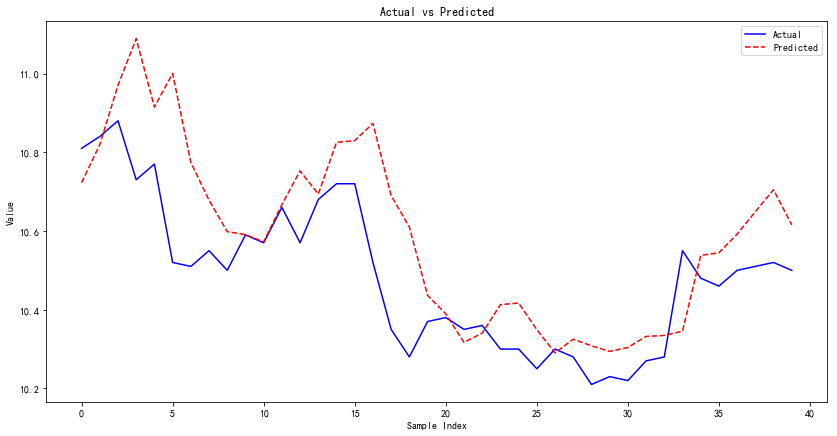

In [90]:
import matplotlib.pyplot as plt

def plot_predictions(actual, predicted):
    """
    绘制实际值与预测值的对比图。
    
    参数:
        actual (numpy.ndarray): 实际值数组。
        predicted (numpy.ndarray): 预测值数组。
    """
    plt.figure(figsize=(14,7))
    plt.plot(actual, label='Actual', color='blue')
    plt.plot(predicted, label='Predicted', color='red', linestyle='--')
    plt.title('Actual vs Predicted')
    plt.xlabel('Sample Index')
    plt.ylabel('Value')
    plt.legend()
    plt.show()

# 使用上面定义的函数绘制图形
plot_predictions(y_test.flatten(), y_pred_transformer.flatten())

##  Adv-ALSTM = Attention-based LSTM + 对抗训练（Adversarial Training）

In [60]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Layer
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import tensorflow as tf


# 自定义注意力层
class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name='attention_weight', shape=(input_shape[-1], 1),
                                 initializer='random_normal', trainable=True)
        self.b = self.add_weight(name='attention_bias', shape=(input_shape[1], 1),
                                 initializer='zeros', trainable=True)
        super(AttentionLayer, self).build(input_shape)

    def call(self, inputs):
        e = tf.tanh(tf.tensordot(inputs, self.W, axes=1) + self.b)
        a = tf.nn.softmax(e, axis=1)
        output = inputs * a
        return tf.reduce_sum(output, axis=1)

    def compute_output_shape(self, input_shape):
        return input_shape[0], input_shape[-1]


# 创建时间序列数据
def create_dataset(X, y, time_steps=1):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        v = X[i:(i + time_steps)]
        Xs.append(v)
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)


# 假设 X_pca 和 y 已准备好
time_steps = 5
X_lstm, y_lstm = create_dataset(X_pca, y, time_steps)

split = int(len(X_lstm) * 0.98)
X_train, X_test = X_lstm[:split], X_lstm[split:]
y_train, y_test = y_lstm[:split], y_lstm[split:]

In [61]:
def build_alstm_model(time_steps, n_features):
    inputs = Input(shape=(time_steps, n_features))
    lstm_out = LSTM(units=64, return_sequences=True)(inputs)
    attention_out = AttentionLayer()(lstm_out)
    dropout = Dropout(0.2)(attention_out)
    outputs = Dense(1)(dropout)
    model = Model(inputs=[inputs], outputs=[outputs])
    return model


model = build_alstm_model(time_steps, X_train.shape[2])
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

In [62]:
def fgsm_attack(model, x, y, epsilon=0.01):
    with tf.GradientTape() as tape:
        tape.watch(x)
        prediction = model(x)
        loss = tf.keras.losses.mean_squared_error(y, prediction)
    # 获取梯度
    gradient = tape.gradient(loss, x)
    # 获取符号
    signed_grad = tf.sign(gradient)
    # 返回对抗样本
    return x + epsilon * signed_grad

In [75]:
epsilon = 0.01  # 控制扰动大小
batch_size = 32
epochs = 30

# 转换为 TensorFlow Dataset
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(1000).batch(batch_size)

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")
    for step, (x_batch, y_batch) in enumerate(train_dataset):
        # 生成对抗样本
        x_adv = fgsm_attack(model, x_batch, y_batch, epsilon)

        # 合并原始数据和对抗数据
        x_combined = tf.concat([x_batch, x_adv], axis=0)
        y_combined = tf.concat([y_batch, y_batch], axis=0)

        # 混洗合并后的数据
        indices = tf.random.shuffle(tf.range(tf.shape(x_combined)[0]))
        x_combined = tf.gather(x_combined, indices)
        y_combined = tf.gather(y_combined, indices)

        # 训练模型
        model.train_on_batch(x_combined, y_combined)


Epoch 1/30

Epoch 2/30

Epoch 3/30

Epoch 4/30

Epoch 5/30

Epoch 6/30

Epoch 7/30

Epoch 8/30

Epoch 9/30

Epoch 10/30

Epoch 11/30

Epoch 12/30

Epoch 13/30

Epoch 14/30

Epoch 15/30

Epoch 16/30

Epoch 17/30

Epoch 18/30

Epoch 19/30

Epoch 20/30

Epoch 21/30

Epoch 22/30

Epoch 23/30

Epoch 24/30

Epoch 25/30

Epoch 26/30

Epoch 27/30

Epoch 28/30

Epoch 29/30

Epoch 30/30


2/2 [==============================] - 0s 2ms/step
Adv-ALSTM - MSE: 0.0155, R²: 0.5471


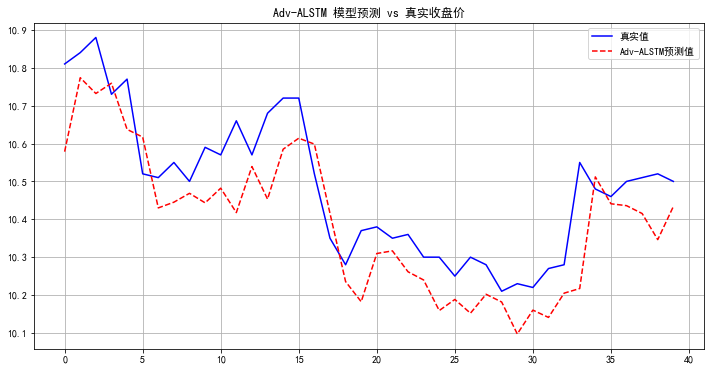

In [76]:
# 预测
y_pred_adv = model.predict(X_test)

# 评估
mse_adv = mean_squared_error(y_test, y_pred_adv)
r2_adv = r2_score(y_test, y_pred_adv)
print(f"Adv-ALSTM - MSE: {mse_adv:.4f}, R²: {r2_adv:.4f}")

# 可视化
plt.figure(figsize=(12, 6))
plt.plot(y_test, label='真实值', color='blue')
plt.plot(y_pred_adv, label='Adv-ALSTM预测值', color='red', linestyle='--')
plt.title('Adv-ALSTM 模型预测 vs 真实收盘价')
plt.legend()
plt.grid(True)
plt.show()

## 多模型预测对比

Epoch 1/20
55/55 [==============================] - 3s 13ms/step - loss: 36.0808 - val_loss: 8.2808
Epoch 2/20
55/55 [==============================] - 0s 6ms/step - loss: 1.4330 - val_loss: 0.5018
Epoch 3/20
55/55 [==============================] - 0s 6ms/step - loss: 0.6282 - val_loss: 0.3727
Epoch 4/20
55/55 [==============================] - 0s 8ms/step - loss: 0.3346 - val_loss: 0.2374
Epoch 5/20
55/55 [==============================] - 0s 7ms/step - loss: 0.2085 - val_loss: 0.2647
Epoch 6/20
55/55 [==============================] - 0s 7ms/step - loss: 0.1440 - val_loss: 0.4086
Epoch 7/20
55/55 [==============================] - 0s 6ms/step - loss: 0.1053 - val_loss: 0.3328
Epoch 8/20
55/55 [==============================] - 0s 7ms/step - loss: 0.0946 - val_loss: 0.3441
Epoch 9/20
55/55 [==============================] - 0s 6ms/step - loss: 0.0842 - val_loss: 0.3212
Epoch 10/20
55/55 [==============================] - 0s 8ms/step - loss: 0.0771 - val_loss: 0.3005
Epoch 11/20
55/55

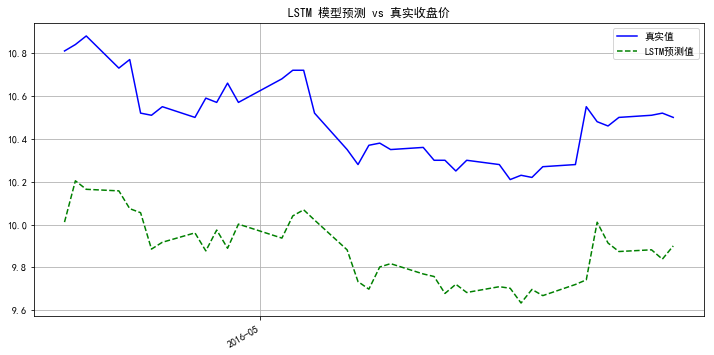

In [92]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 假设 X_pca 和 y 已经准备好，并且 dates 是对应的时间序列
# from your previous code:
# X_train, X_test, y_train, y_test = ...
# dates = pd.to_datetime(...) # 时间列

# 构建并训练 LSTM 模型
model_lstm = Sequential()
model_lstm.add(LSTM(128, input_shape=(X_train.shape[1], X_train.shape[2])))
model_lstm.add(Dense(1))
model_lstm.compile(optimizer='adam', loss='mse')

history = model_lstm.fit(X_train, y_train, epochs=20, batch_size=32,
                          validation_split=0.1, verbose=1)

# 预测
y_pred_lstm = model_lstm.predict(X_test)

# 评估
mse_lstm = mean_squared_error(y_test, y_pred_lstm)
r2_lstm = r2_score(y_test, y_pred_lstm)
print(f"LSTM - MSE: {mse_lstm:.4f}, R²: {r2_lstm:.4f}")

# 可视化真实值和 LSTM 预测值（可选）
test_dates = dates.iloc[-len(y_test):]

plt.figure(figsize=(12, 6))
plt.plot(test_dates, y_test, label='真实值', color='blue')
plt.plot(test_dates, y_pred_lstm, label='LSTM预测值', color='green', linestyle='--')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.gcf().autofmt_xdate()
plt.title('LSTM 模型预测 vs 真实收盘价')
plt.legend()
plt.grid(True)
plt.show()


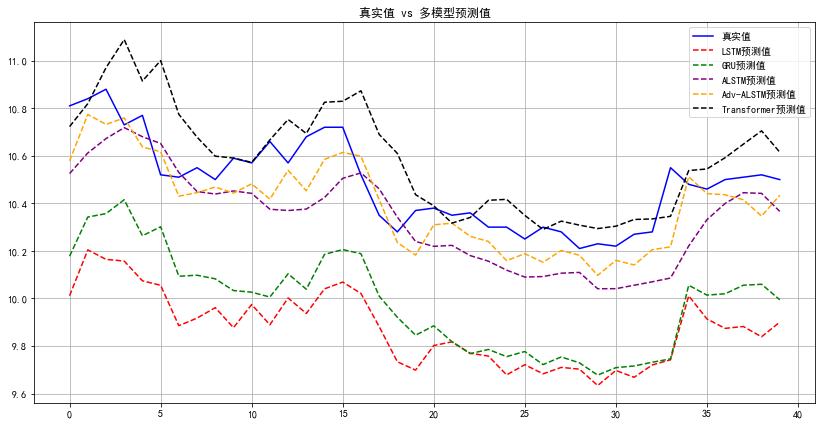

In [103]:
# 多模型对比绘图函数
def plot_multiple_predictions(actual, predictions_dict):
    """
    在同一张图中绘制实际值与多个模型预测值的对比图。
    
    参数:
        actual (numpy.ndarray): 实际值数组。
        predictions_dict (dict): 键为模型名称，值为预测值数组的字典。
    """
    plt.figure(figsize=(14,7))
    plt.plot(actual, label='真实值', color='blue')
    
    # 定义一些常用颜色
    colors = ['red', 'green', 'purple', 'orange', 'black']
    
    for idx, (model_name, predicted) in enumerate(predictions_dict.items()):
        plt.plot(predicted.flatten(), label=model_name, color=colors[idx], linestyle='--')
    
    plt.title('真实值 vs 多模型预测值')
    plt.legend()
    plt.grid(True)
    plt.show()

# 准备多模型预测结果（确保已定义：y_pred_gru, y_pred）
predictions_to_plot = {
    'LSTM预测值': y_pred_lstm.flatten(),
     'GRU预测值': y_pred_gru.flatten(),
    'ALSTM预测值': y_pred.flatten(),
    'Adv-ALSTM预测值': y_pred_adv,
    'Transformer预测值': y_pred_transformer.flatten(),
}

# 绘制多模型预测曲线
plot_multiple_predictions(y_test.flatten(), predictions_to_plot)